# DeepFM Model Training & Evaluation
### MS MARCO Passage Ranking
This notebook loads the engineered features from `df_features_v2.pkl`, fits a DeepFM model using `deepctr-torch`, and evaluates performance with robust ranking metrics.

## 1. Load Dependencies

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import math
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict

import torch
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)

from deepctr_torch.inputs import SparseFeat, DenseFeat, get_feature_names
from deepctr_torch.models import DeepFM

print(f"PyTorch:      {torch.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Numpy:        {np.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

PyTorch:      2.2.0
Pandas:       2.2.0
Numpy:        1.26.4
CUDA available: False
Using device: cpu


## 2. Load Engineered Features

In [2]:
df = pd.read_pickle('df_features_v2.pkl')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['is_selected'].value_counts())
print(f"Positive rate: {df['is_selected'].mean():.3%}")

Dataset shape: (54281, 27)
Columns: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers', 'passage_text', 'is_selected', 'label', 'query_length', 'passage_length', 'length_ratio', 'exact_match', 'query_term_coverage', 'jaccard_similarity', 'tfidf_cosine_sim', 'bm25_score', 'passage_position', 'jaccard_clean', 'term_coverage_clean', 'has_question_mark', 'query_word_count', 'trigram_overlap', 'bm25_x_tfidf', 'bm25_x_term_coverage', 'tfidf_x_jaccard', 'overlap_per_passage_len']

Class distribution:
is_selected
0    48482
1     5799
Name: count, dtype: int64
Positive rate: 10.683%


## 3. Define Features
All features are treated as dense (continuous) inputs to DeepFM.
`query_type` is the only categorical (sparse) feature.

In [3]:
# ── Dense (continuous) features ──────────────────────────────────────────────
DENSE_FEATURES = [
    'query_length',
    'passage_length',
    'length_ratio',
    'exact_match',
    'query_term_coverage',
    'jaccard_similarity',
    'tfidf_cosine_sim',
    'bm25_score',
    'passage_position',
    # enriched features from feature engineering notebook
    'jaccard_clean',
    'term_coverage_clean',
    'has_question_mark',
    'query_word_count',
    'trigram_overlap',
    'bm25_x_tfidf',
    'bm25_x_term_coverage',
    'tfidf_x_jaccard',
    'overlap_per_passage_len',
]

# ── Sparse (categorical) features ────────────────────────────────────────────
SPARSE_FEATURES = ['query_type']   # 0=other, 1=question, 2=how-to

TARGET = 'is_selected'

# Filter to only columns that actually exist in the dataframe
DENSE_FEATURES  = [f for f in DENSE_FEATURES  if f in df.columns]
SPARSE_FEATURES = [f for f in SPARSE_FEATURES if f in df.columns]

print(f"Dense features  ({len(DENSE_FEATURES)}): {DENSE_FEATURES}")
print(f"Sparse features ({len(SPARSE_FEATURES)}): {SPARSE_FEATURES}")

Dense features  (18): ['query_length', 'passage_length', 'length_ratio', 'exact_match', 'query_term_coverage', 'jaccard_similarity', 'tfidf_cosine_sim', 'bm25_score', 'passage_position', 'jaccard_clean', 'term_coverage_clean', 'has_question_mark', 'query_word_count', 'trigram_overlap', 'bm25_x_tfidf', 'bm25_x_term_coverage', 'tfidf_x_jaccard', 'overlap_per_passage_len']
Sparse features (1): ['query_type']


## 4. Train / Validation / Test Split
Split at the **query level** to prevent data leakage — all passages for a given query must be in the same split.

In [4]:
unique_qids = df['query_id'].unique()

train_qids, temp_qids = train_test_split(unique_qids, test_size=0.30, random_state=42)
val_qids,  test_qids  = train_test_split(temp_qids,   test_size=0.50, random_state=42)

train_df = df[df['query_id'].isin(train_qids)].reset_index(drop=True)
val_df   = df[df['query_id'].isin(val_qids)].reset_index(drop=True)
test_df  = df[df['query_id'].isin(test_qids)].reset_index(drop=True)

print(f"Train: {len(train_df):,} rows | {len(train_qids):,} queries | "
      f"positive rate: {train_df[TARGET].mean():.3%}")
print(f"Val:   {len(val_df):,} rows | {len(val_qids):,} queries | "
      f"positive rate: {val_df[TARGET].mean():.3%}")
print(f"Test:  {len(test_df):,} rows | {len(test_qids):,} queries | "
      f"positive rate: {test_df[TARGET].mean():.3%}")

Train: 37,986 rows | 3,804 queries | positive rate: 10.691%
Val:   8,149 rows | 815 queries | positive rate: 10.713%
Test:  8,146 rows | 816 queries | positive rate: 10.619%


## 5. Preprocessing

In [5]:
# ── Explicit numeric conversion BEFORE scaling ────────────────────────────────
print("Converting features to numeric...")

for col in DENSE_FEATURES:
    for split in [train_df, val_df, test_df]:
        split[col] = pd.to_numeric(split[col], errors='coerce').fillna(0).astype(np.float32)

for col in SPARSE_FEATURES:
    for split in [train_df, val_df, test_df]:
        split[col] = pd.to_numeric(split[col], errors='coerce').fillna(0).astype(np.int32)

for split in [train_df, val_df, test_df]:
    split[TARGET] = pd.to_numeric(split[TARGET], errors='coerce').fillna(0).astype(np.float32)

# ── Verify nothing is still object dtype ──────────────────────────────────────
print("\nDtype check before scaling:")
issues = []
for col in DENSE_FEATURES + SPARSE_FEATURES + [TARGET]:
    dtype = train_df[col].dtype
    if dtype == object:
        issues.append(col)
    else:
        print(f"  {col:<30} {str(dtype)}")

if issues:
    print(f"\nWARNING — still object dtype: {issues}")
else:
    print("\nAll features are numeric. Safe to scale.")

Converting features to numeric...

Dtype check before scaling:
  query_length                   float32
  passage_length                 float32
  length_ratio                   float32
  exact_match                    float32
  query_term_coverage            float32
  jaccard_similarity             float32
  tfidf_cosine_sim               float32
  bm25_score                     float32
  passage_position               float32
  jaccard_clean                  float32
  term_coverage_clean            float32
  has_question_mark              float32
  query_word_count               float32
  trigram_overlap                float32
  bm25_x_tfidf                   float32
  bm25_x_term_coverage           float32
  tfidf_x_jaccard                float32
  overlap_per_passage_len        float32
  query_type                     int32
  is_selected                    float32

All features are numeric. Safe to scale.


In [6]:
# ── Scale dense features (fit on train only) ──────────────────────────────────
scaler = StandardScaler()
train_df[DENSE_FEATURES] = scaler.fit_transform(train_df[DENSE_FEATURES])
val_df[DENSE_FEATURES]   = scaler.transform(val_df[DENSE_FEATURES])
test_df[DENSE_FEATURES]  = scaler.transform(test_df[DENSE_FEATURES])

# ── Encode sparse features ────────────────────────────────────────────────────
# query_type has values 0,1,2 — already integer encoded, just clip to be safe
if 'query_type' in SPARSE_FEATURES:
    for split in [train_df, val_df, test_df]:
        split['query_type'] = split['query_type'].astype(int).clip(0, 2)

print("Scaling complete.")
print(train_df[DENSE_FEATURES].describe().round(3))

Scaling complete.
       query_length  passage_length  length_ratio  exact_match  \
count     37986.000       37986.000     37986.000    37986.000   
mean          0.000           0.000        -0.000       -0.000   
std           1.000           1.000         1.000        1.000   
min          -1.516          -2.579        -1.497       -0.103   
25%          -0.742          -0.589        -0.641       -0.103   
50%           0.032          -0.171        -0.203       -0.103   
75%           0.420           0.301         0.368       -0.103   
max           9.323           7.578        20.602        9.718   

       query_term_coverage  jaccard_similarity  tfidf_cosine_sim  bm25_score  \
count            37986.000           37986.000         37986.000   37986.000   
mean                 0.000              -0.000             0.000       0.000   
std                  1.000               1.000             1.000       1.000   
min                 -1.846              -1.378            -1.385   

## 6. Build DeepFM Feature Columns

In [7]:
# DeepFM expects a list of feature column definitions
fixlen_feature_columns = (
    # Sparse features: need vocabulary size and embedding dimension
    [SparseFeat(feat,
                vocabulary_size=df[feat].nunique() + 1,
                embedding_dim=4)
     for feat in SPARSE_FEATURES]
    +
    # Dense features: just need the dimension (1 per feature)
    [DenseFeat(feat, 1)
     for feat in DENSE_FEATURES]
)

# linear_feature_columns: used by the FM component
# dnn_feature_columns:    used by the DNN component
# Both receive the same columns — shared embeddings
linear_feature_columns = fixlen_feature_columns
dnn_feature_columns    = fixlen_feature_columns

feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)
print(f"Feature names passed to DeepFM: {feature_names}")

Feature names passed to DeepFM: ['query_type', 'query_length', 'passage_length', 'length_ratio', 'exact_match', 'query_term_coverage', 'jaccard_similarity', 'tfidf_cosine_sim', 'bm25_score', 'passage_position', 'jaccard_clean', 'term_coverage_clean', 'has_question_mark', 'query_word_count', 'trigram_overlap', 'bm25_x_tfidf', 'bm25_x_term_coverage', 'tfidf_x_jaccard', 'overlap_per_passage_len']


## 7. Prepare Model Inputs

In [8]:
def build_input(data: pd.DataFrame, feature_names: list) -> dict:
    """Convert a dataframe split into the dict format DeepFM expects."""
    return {name: data[name].values for name in feature_names}

train_model_input = build_input(train_df, feature_names)
val_model_input   = build_input(val_df,   feature_names)
test_model_input  = build_input(test_df,  feature_names)

# Class imbalance weight
n_neg     = (train_df[TARGET] == 0).sum()
n_pos     = (train_df[TARGET] == 1).sum()
pos_weight = n_neg / n_pos
print(f"pos_weight for loss function: {pos_weight:.2f}  "
      f"(1 positive per ~{pos_weight:.0f} negatives)")

pos_weight for loss function: 8.35  (1 positive per ~8 negatives)


#### Datatype check

In [9]:
print("Dtypes check:")
for col in DENSE_FEATURES + SPARSE_FEATURES:
    dtype = train_df[col].dtype
    if dtype == object:
        print(f"  WARNING: {col} is still object type")
print("Done — you can safely run model.fit()")

Dtypes check:
Done — you can safely run model.fit()


## 8. Instantiate & Train DeepFM

In [10]:
model = DeepFM(
    linear_feature_columns = linear_feature_columns,
    dnn_feature_columns    = dnn_feature_columns,
    dnn_hidden_units       = (256, 128, 64),   # 3-layer DNN
    dnn_dropout            = 0.2,
    l2_reg_embedding       = 1e-4,
    l2_reg_linear          = 1e-4,
    l2_reg_dnn             = 1e-4,
    task                   = 'binary',
    device                 = DEVICE,
)

model.compile(
    optimizer = 'adam',
    loss      = 'binary_crossentropy',
    metrics   = ['binary_crossentropy', 'auc'],
)

print("Model architecture:")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.0
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model architecture:
DeepFM(
  (embedding_dict): ModuleDict(
    (query_type): Embedding(4, 4)
  )
  (linear_model): Linear(
    (embedding_dict): ModuleDict(
      (query_type): Embedding(4, 1)
    )
  )
  (out): PredictionLayer()
  (fm): FM()
  (dnn): DNN(
    (dropout): Dropout(p=0.2, inplace=False)
    (linears): ModuleList(
      (0): Linear(in_features=22, out_features=256, bias=True)
      (1): Linear(in_features=256, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
    (activation_layers): ModuleList(
      (0-2): 3 x ReLU(inplace=True)
    )
  )
  (dnn_linear): Linear(in_features=64, out_features=1, bias=False)
)

Total trainable parameters: 47,143


In [11]:
history = model.fit(
    x               = train_model_input,
    y               = train_df[TARGET].values,
    batch_size      = 512,
    epochs          = 20,
    verbose         = 1,
    validation_data = (val_model_input, val_df[TARGET].values),
)

cpu
Train on 37986 samples, validate on 8149 samples, 75 steps per epoch


75it [00:00, 178.93it/s]


Epoch 1/20
0s - loss:  0.3979 - binary_crossentropy:  0.3977 - auc:  0.6612 - val_binary_crossentropy:  0.3232 - val_auc:  0.6682


75it [00:00, 265.94it/s]


Epoch 2/20
0s - loss:  0.3205 - binary_crossentropy:  0.3206 - auc:  0.6815 - val_binary_crossentropy:  0.3230 - val_auc:  0.6687


...

Epoch 18/20
0s - loss:  0.3181 - binary_crossentropy:  0.3185 - auc:  0.6896 - val_binary_crossentropy:  0.3212 - val_auc:  0.6783


75it [00:00, 227.83it/s]


Epoch 19/20
0s - loss:  0.3177 - binary_crossentropy:  0.3174 - auc:  0.6910 - val_binary_crossentropy:  0.3206 - val_auc:  0.6792


75it [00:00, 266.95it/s]

Epoch 20/20
0s - loss:  0.3177 - binary_crossentropy:  0.3170 - auc:  0.6892 - val_binary_crossentropy:  0.3207 - val_auc:  0.6782


## 9. Training Curves

In [12]:
print(history.history.keys())

dict_keys(['loss', 'binary_crossentropy', 'auc', 'val_binary_crossentropy', 'val_auc'])


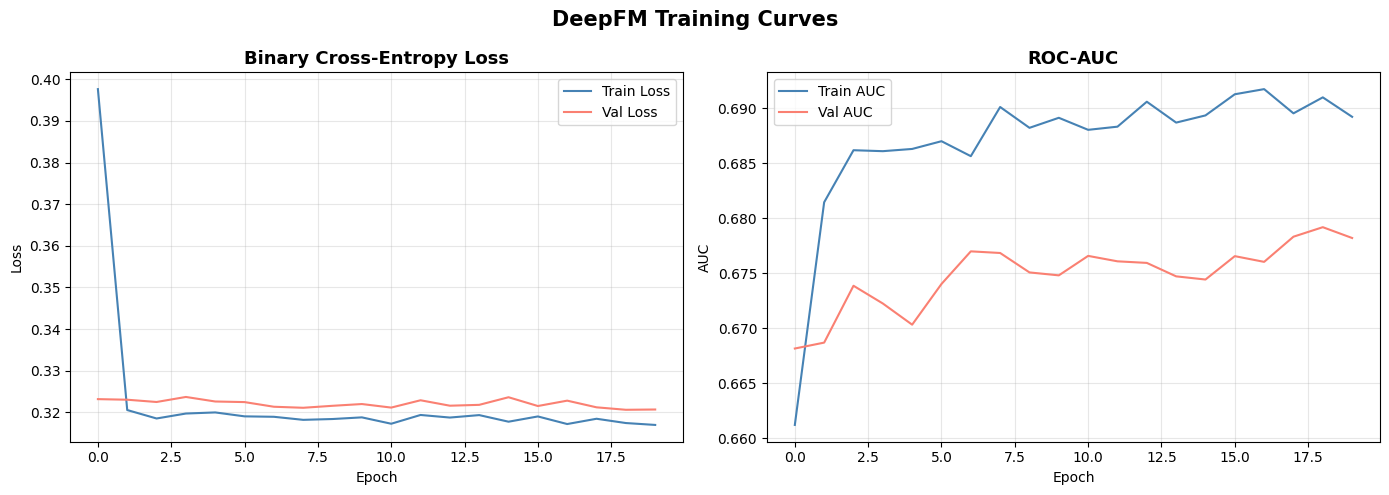

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curve ────────────────────────────────────────────────────────────────
axes[0].plot(history.history['binary_crossentropy'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_binary_crossentropy'], label='Val Loss',   color='salmon')
axes[0].set_title('Binary Cross-Entropy Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── AUC curve ─────────────────────────────────────────────────────────────────
axes[1].plot(history.history['auc'],     label='Train AUC', color='steelblue')
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='salmon')
axes[1].set_title('ROC-AUC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DeepFM Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Generate Predictions on Test Set

In [14]:
# Raw relevance scores (probabilities) from DeepFM
test_preds = model.predict(test_model_input, batch_size=512)
test_df['deepfm_score'] = test_preds
test_labels = test_df[TARGET].values

print(f"Predictions shape: {test_preds.shape}")
print(f"Score range: [{test_preds.min():.4f}, {test_preds.max():.4f}]")
print(f"Mean predicted score: {test_preds.mean():.4f}")

Predictions shape: (8146, 1)
Score range: [0.0017, 0.5054]
Mean predicted score: 0.1086


## 11. Evaluation Metrics

### 11.1 Pointwise Metrics (pair-level)

In [15]:
# ── ROC-AUC ───────────────────────────────────────────────────────────────────
roc_auc = roc_auc_score(test_labels, test_preds)

# ── Average Precision (PR-AUC) ────────────────────────────────────────────────
# More informative than ROC-AUC for imbalanced datasets
pr_auc = average_precision_score(test_labels, test_preds)

# ── Binary classification at threshold 0.5 ───────────────────────────────────
threshold    = 0.5
binary_preds = (test_preds >= threshold).astype(int)

print("=" * 50)
print("POINTWISE METRICS (pair-level)")
print("=" * 50)
print(f"ROC-AUC:              {roc_auc:.4f}")
print(f"PR-AUC:               {pr_auc:.4f}")
print(f"\nClassification Report (threshold={threshold}):")
print(classification_report(test_labels, binary_preds,
                             target_names=['Not Relevant', 'Relevant']))

POINTWISE METRICS (pair-level)
ROC-AUC:              0.6836
PR-AUC:               0.1986

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

Not Relevant       0.89      1.00      0.94      7281
    Relevant       1.00      0.00      0.00       865

    accuracy                           0.89      8146
   macro avg       0.95      0.50      0.47      8146
weighted avg       0.91      0.89      0.84      8146



### 11.2 Ranking Metrics (query-level)
These are the metrics that matter most for search — they evaluate how well the model **ranks** passages per query.

In [16]:
def ndcg_at_k(group: pd.DataFrame, score_col: str, k: int = 10) -> float:
    """NDCG@K for a single query group."""
    group = group.sort_values(score_col, ascending=False).head(k)
    dcg   = sum(rel / math.log2(i + 2)
                for i, rel in enumerate(group[TARGET]))
    ideal = group.sort_values(TARGET, ascending=False)
    idcg  = sum(rel / math.log2(i + 2)
                for i, rel in enumerate(ideal[TARGET]))
    return dcg / idcg if idcg > 0 else 0.0


def mrr_at_k(group: pd.DataFrame, score_col: str, k: int = 10) -> float:
    """MRR@K for a single query group."""
    group = group.sort_values(score_col, ascending=False).head(k).reset_index(drop=True)
    for i, row in group.iterrows():
        if row[TARGET] == 1:
            return 1.0 / (i + 1)
    return 0.0


def precision_at_k(group: pd.DataFrame, score_col: str, k: int = 10) -> float:
    """Precision@K for a single query group."""
    group = group.sort_values(score_col, ascending=False).head(k)
    return group[TARGET].sum() / k


def recall_at_k(group: pd.DataFrame, score_col: str, k: int = 10) -> float:
    """Recall@K for a single query group."""
    total_relevant = group[TARGET].sum()
    if total_relevant == 0:
        return 0.0
    top_k = group.sort_values(score_col, ascending=False).head(k)
    return top_k[TARGET].sum() / total_relevant


def hit_rate_at_k(group: pd.DataFrame, score_col: str, k: int = 10) -> float:
    """Hit Rate@K — 1 if at least one relevant passage in top-K."""
    top_k = group.sort_values(score_col, ascending=False).head(k)
    return 1.0 if top_k[TARGET].sum() > 0 else 0.0


def compute_ranking_metrics(data: pd.DataFrame, score_col: str,
                             k_values=(1, 3, 5, 10)) -> dict:
    """Compute all ranking metrics across all queries."""
    results = {}
    for k in k_values:
        grouped = data.groupby('query_id')
        results[f'NDCG@{k}']      = grouped.apply(lambda g: ndcg_at_k(g, score_col, k)).mean()
        results[f'MRR@{k}']       = grouped.apply(lambda g: mrr_at_k(g, score_col, k)).mean()
        results[f'P@{k}']         = grouped.apply(lambda g: precision_at_k(g, score_col, k)).mean()
        results[f'Recall@{k}']    = grouped.apply(lambda g: recall_at_k(g, score_col, k)).mean()
        results[f'HitRate@{k}']   = grouped.apply(lambda g: hit_rate_at_k(g, score_col, k)).mean()
    return results


# Compute for both BM25 baseline and DeepFM
bm25_metrics   = compute_ranking_metrics(test_df, 'bm25_score')
deepfm_metrics = compute_ranking_metrics(test_df, 'deepfm_score')

# Display side by side
metrics_df = pd.DataFrame({
    'BM25 Baseline': bm25_metrics,
    'DeepFM':        deepfm_metrics
})
metrics_df['Delta'] = metrics_df['DeepFM'] - metrics_df['BM25 Baseline']
metrics_df['Improvement %'] = (metrics_df['Delta'] / metrics_df['BM25 Baseline'] * 100).round(2)

print("=" * 65)
print("RANKING METRICS — DeepFM vs BM25 Baseline")
print("=" * 65)
print(metrics_df.round(4).to_string())

RANKING METRICS — DeepFM vs BM25 Baseline
            BM25 Baseline  DeepFM   Delta  Improvement %
NDCG@1             0.2439  0.2672  0.0233           9.55
MRR@1              0.2439  0.2672  0.0233           9.55
P@1                0.2439  0.2672  0.0233           9.55
Recall@1           0.2350  0.2555  0.0205           8.74
HitRate@1          0.2439  0.2672  0.0233           9.55
NDCG@3             0.4334  0.4533  0.0199           4.58
MRR@3              0.3856  0.4067  0.0210           5.46
P@3                0.1965  0.2006  0.0041           2.08
Recall@3           0.5585  0.5705  0.0119           2.14
HitRate@3          0.5735  0.5907  0.0172           2.99
NDCG@5             0.5172  0.5347  0.0175           3.39
MRR@5              0.4320  0.4519  0.0199           4.60
P@5                0.1615  0.1632  0.0017           1.06
Recall@5           0.7662  0.7742  0.0080           1.04
HitRate@5          0.7782  0.7880  0.0098           1.26
NDCG@10            0.5894  0.6033  0.0139     

### 11.3 ROC and Precision-Recall Curves

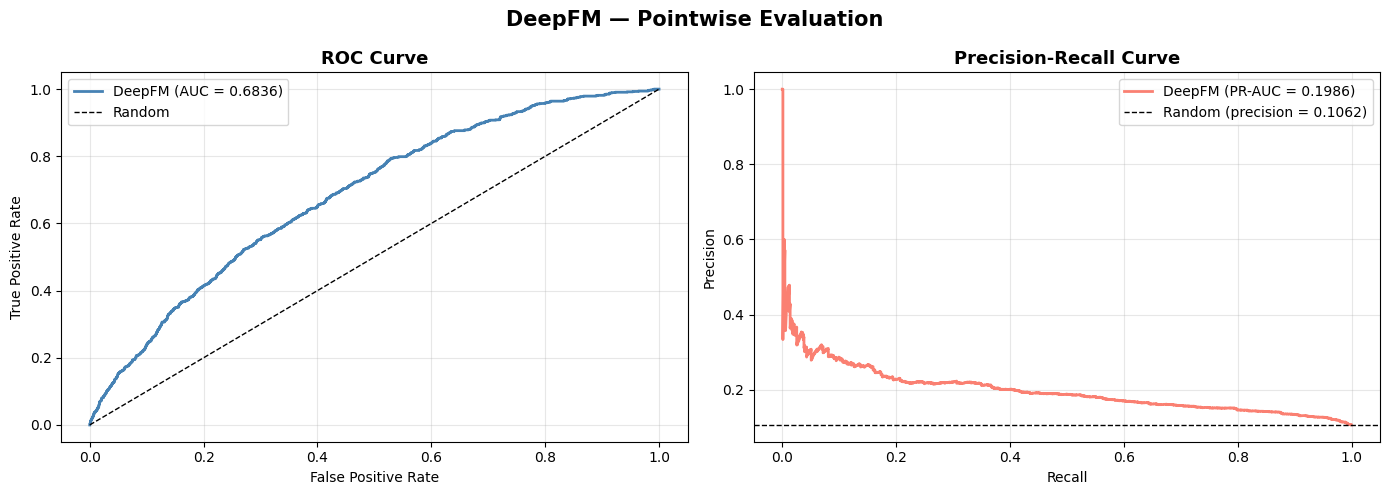

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(test_labels, test_preds)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'DeepFM (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(test_labels, test_preds)
axes[1].plot(recall, precision, color='salmon', lw=2,
             label=f'DeepFM (PR-AUC = {pr_auc:.4f})')
baseline_precision = test_labels.mean()
axes[1].axhline(y=baseline_precision, color='k', linestyle='--', lw=1,
                label=f'Random (precision = {baseline_precision:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DeepFM — Pointwise Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.4 Ranking Metrics Bar Chart

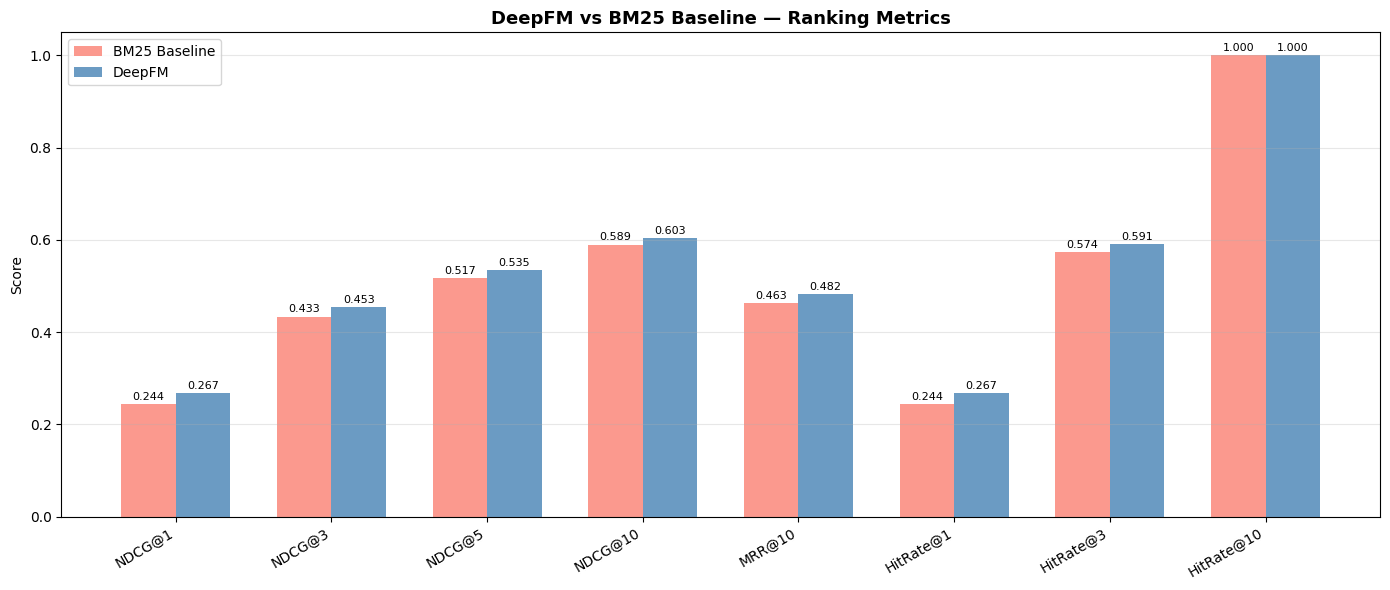

In [18]:
plot_metrics = ['NDCG@1','NDCG@3','NDCG@5','NDCG@10',
                'MRR@10','HitRate@1','HitRate@3','HitRate@10']
plot_df = metrics_df.loc[plot_metrics, ['BM25 Baseline', 'DeepFM']]

x      = np.arange(len(plot_metrics))
width  = 0.35
fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, plot_df['BM25 Baseline'], width,
               label='BM25 Baseline', color='salmon',    alpha=0.8)
bars2 = ax.bar(x + width/2, plot_df['DeepFM'],        width,
               label='DeepFM',        color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('DeepFM vs BM25 Baseline — Ranking Metrics',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('ranking_metrics_bar.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.5 Confusion Matrix

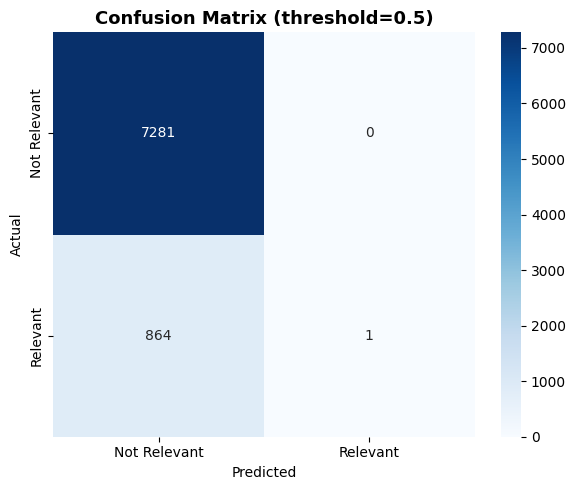

In [19]:
cm = confusion_matrix(test_labels, binary_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Relevant', 'Relevant'],
            yticklabels=['Not Relevant', 'Relevant'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (threshold={threshold})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.6 Score Distribution by Label

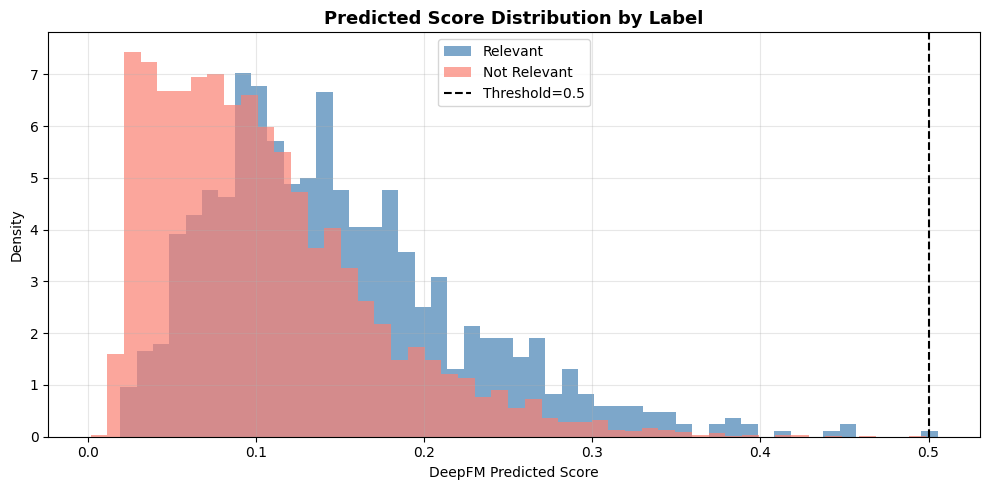

Mean score — Relevant:     0.1485
Mean score — Not Relevant: 0.1039


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

test_df[test_df[TARGET] == 1]['deepfm_score'].hist(
    bins=50, alpha=0.7, color='steelblue', label='Relevant',     density=True, ax=ax)
test_df[test_df[TARGET] == 0]['deepfm_score'].hist(
    bins=50, alpha=0.7, color='salmon',    label='Not Relevant', density=True, ax=ax)

ax.axvline(x=threshold, color='black', linestyle='--', label=f'Threshold={threshold}')
ax.set_xlabel('DeepFM Predicted Score')
ax.set_ylabel('Density')
ax.set_title('Predicted Score Distribution by Label',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Mean score — Relevant:     {test_df[test_df[TARGET]==1]['deepfm_score'].mean():.4f}")
print(f"Mean score — Not Relevant: {test_df[test_df[TARGET]==0]['deepfm_score'].mean():.4f}")

### 11.7 Feature Importance (Gradient-based)

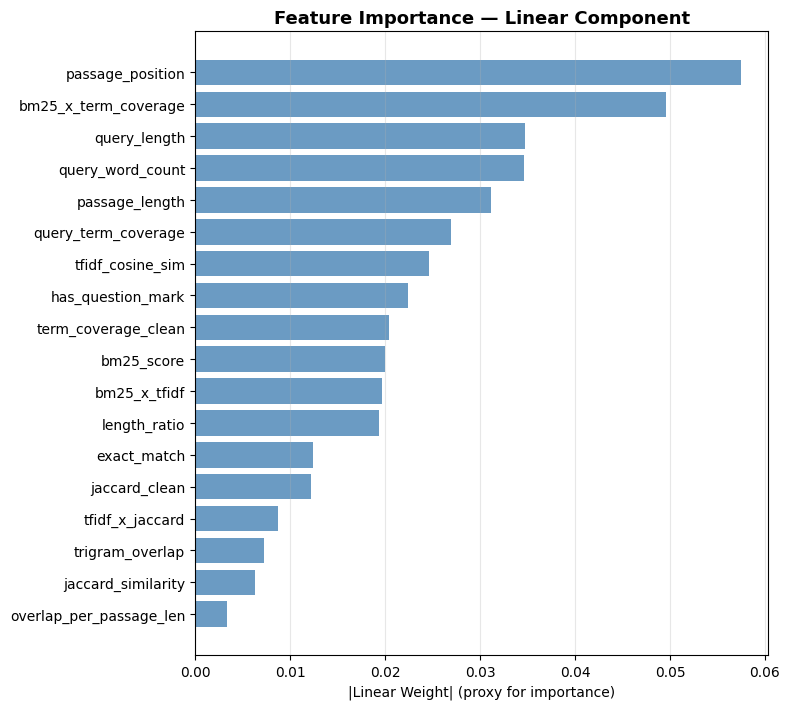

In [21]:
# Approximate feature importance via DNN input gradient magnitudes
model.eval()

sample = test_df.head(1000)
sample_input = build_input(sample, feature_names)

# Convert to tensors with gradients
dense_tensors = {
    name: torch.tensor(sample_input[name].reshape(-1, 1),
                       dtype=torch.float32, requires_grad=True)
    for name in DENSE_FEATURES
}

# Use linear layer weights as a proxy for feature importance
# (deepctr-torch exposes the linear layer weights directly)
try:
    linear_weights = model.linear_model.weight.data.cpu().numpy().flatten()
    # Map weights back to dense feature names
    importance_df = pd.DataFrame({
        'feature':    DENSE_FEATURES[:len(linear_weights)],
        'importance': np.abs(linear_weights[:len(DENSE_FEATURES)])
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(5, len(DENSE_FEATURES) * 0.4)))
    ax.barh(importance_df['feature'], importance_df['importance'],
            color='steelblue', alpha=0.8)
    ax.set_xlabel('|Linear Weight| (proxy for importance)')
    ax.set_title('Feature Importance — Linear Component',
                 fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not extract linear weights directly: {e}")
    print("Skipping feature importance plot.")

## 12. Final Summary

In [22]:
print("=" * 65)
print("FINAL MODEL SUMMARY")
print("=" * 65)
print(f"\nModel:              DeepFM (deepctr-torch)")
print(f"DNN layers:         (256, 128, 64)")
print(f"Dropout:            0.2")
print(f"Trainable params:   {total_params:,}")
print(f"Device:             {DEVICE}")
print(f"\n--- Pointwise ---")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC:             {pr_auc:.4f}")
print(f"\n--- Ranking (DeepFM vs BM25) ---")
for metric in ['NDCG@10', 'MRR@10', 'HitRate@10']:
    bm25_val   = bm25_metrics[metric]
    deepfm_val = deepfm_metrics[metric]
    delta      = deepfm_val - bm25_val
    direction  = '+' if delta >= 0 else ''
    print(f"{metric:<15} BM25={bm25_val:.4f}  "
          f"DeepFM={deepfm_val:.4f}  ({direction}{delta:.4f})")
print("=" * 65)

FINAL MODEL SUMMARY

Model:              DeepFM (deepctr-torch)
DNN layers:         (256, 128, 64)
Dropout:            0.2
Trainable params:   47,143
Device:             cpu

--- Pointwise ---
ROC-AUC:            0.6836
PR-AUC:             0.1986

--- Ranking (DeepFM vs BM25) ---
NDCG@10         BM25=0.5894  DeepFM=0.6033  (+0.0139)
MRR@10          BM25=0.4625  DeepFM=0.4816  (+0.0191)
HitRate@10      BM25=1.0000  DeepFM=1.0000  (+0.0000)


## 13. Save Model

In [23]:
torch.save(model.state_dict(), 'deepfm_msmarco_amulya.pth')
pickle.dump(scaler, open('feature_scaler_amulya.pkl', 'wb'))
print("Model saved to deepfm_msmarco_amulya.pth")
print("Scaler saved to feature_scaler_amulya.pkl")

Model saved to deepfm_msmarco_amulya.pth
Scaler saved to feature_scaler_amulya.pkl
